Analyse des données 

In [1]:
import sys
!{sys.executable} -m pip install geopandas contextily

In [2]:
import sys
!{sys.executable} -m pip install ggplot

In [3]:
import pandas as pd
from plotnine import *

# Chargement des données
df = pd.read_csv(r"C:\Users\PC\Documents\Projet_Chlordecone_2026\data\Donnees_Chlordecone_Nettoyees_2026.csv", sep=';')

print("Données prêtes pour l'analyse ggplot !")
df.head()

Données prêtes pour l'analyse ggplot !


,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,0.07,2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,0.07,2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,0.07,3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,0.07,1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,0.07,2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_ydensity : Removed 1336 rows containing non-finite values.
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 1336 rows containing non-finite values.


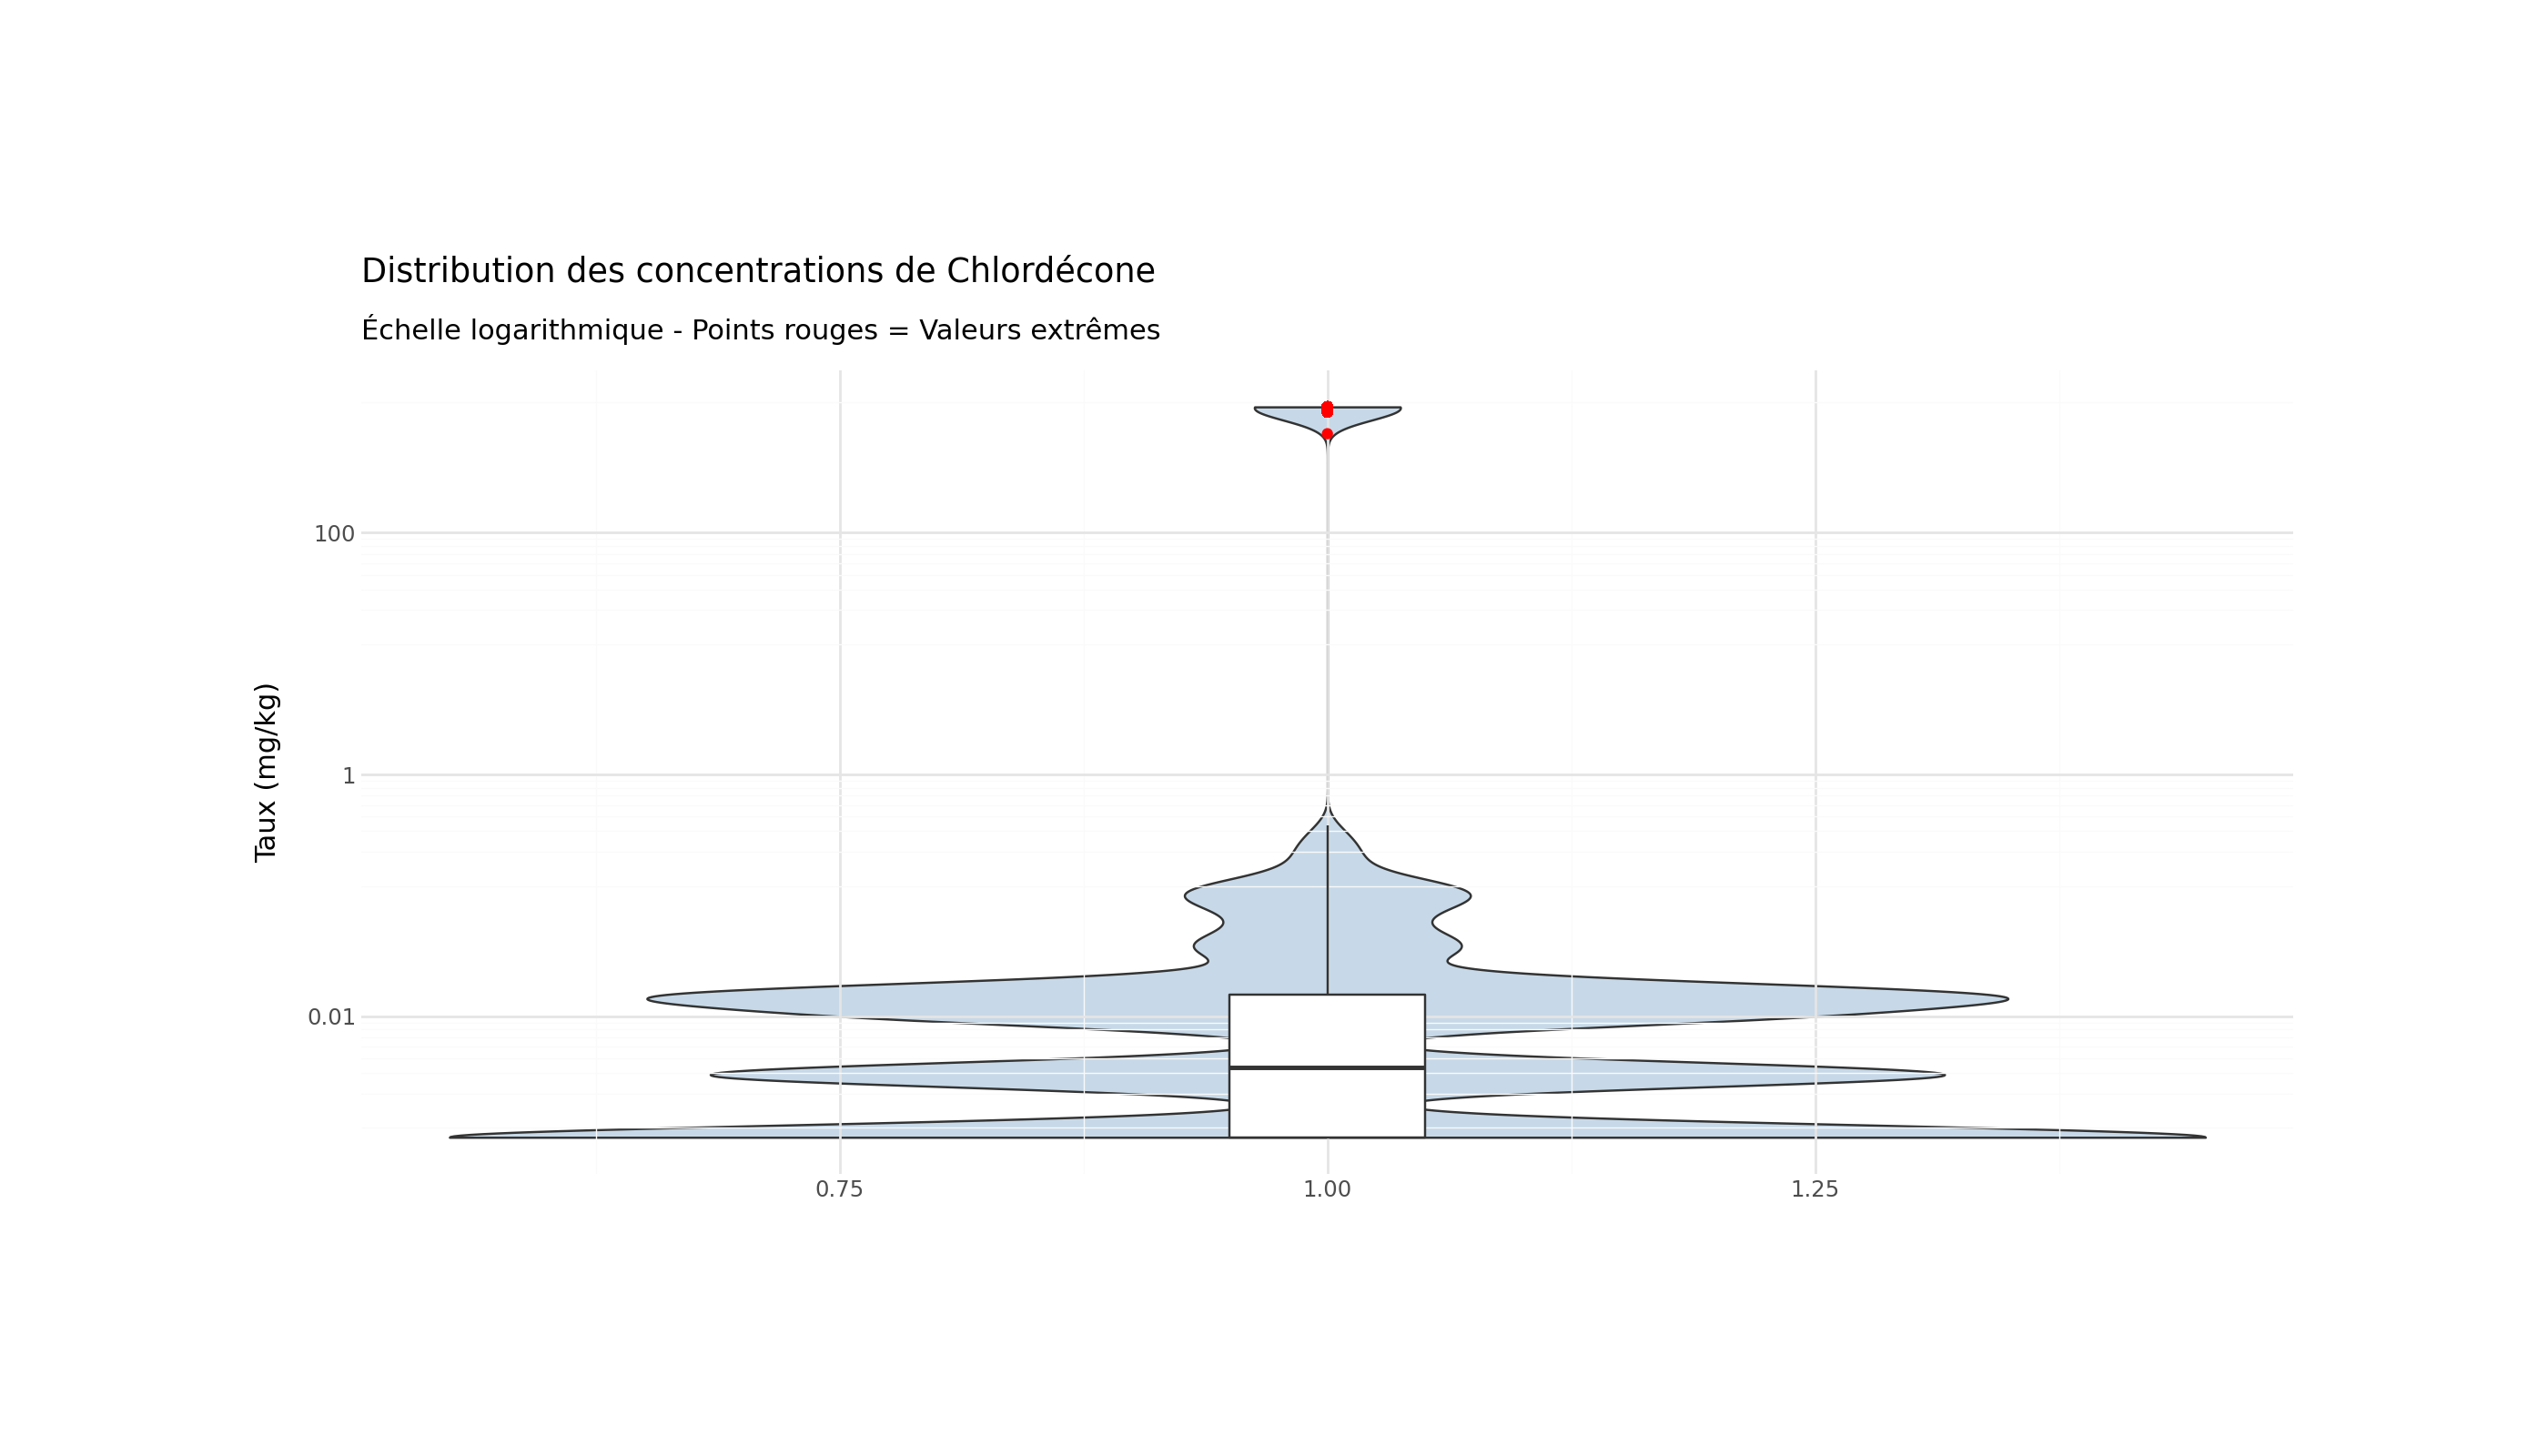

In [4]:
(
    ggplot(df, aes(x='1', y='Taux_5b_hydro'))
    + geom_violin(fill="steelblue", alpha=0.3)
    + geom_boxplot(width=0.1, fill="white", outlier_color="red")
    + scale_y_log10() # Très important : les taux varient souvent de 0.001 à 10.0
    + labs(title="Distribution des concentrations de Chlordécone", 
           subtitle="Échelle logarithmique - Points rouges = Valeurs extrêmes",
           y="Taux (mg/kg)", x="")
    + theme_minimal()
    + theme(
        figure_size=(14, 8),         
        plot_margin=0.1,        
        legend_position='right',      
        legend_box_margin=20         
    )
)

Ici on voit une présence de choredécone répartie avec de faibles taux comprises en majorité en 0.001 et 0.6 mg/kg
On voit aussi des concentrations de chloredécone extrêmement élevées dans certains cas (plus de 100 mg/kg)

Maintenant voyons exactement quelle sont les communes concernés par cette pollution

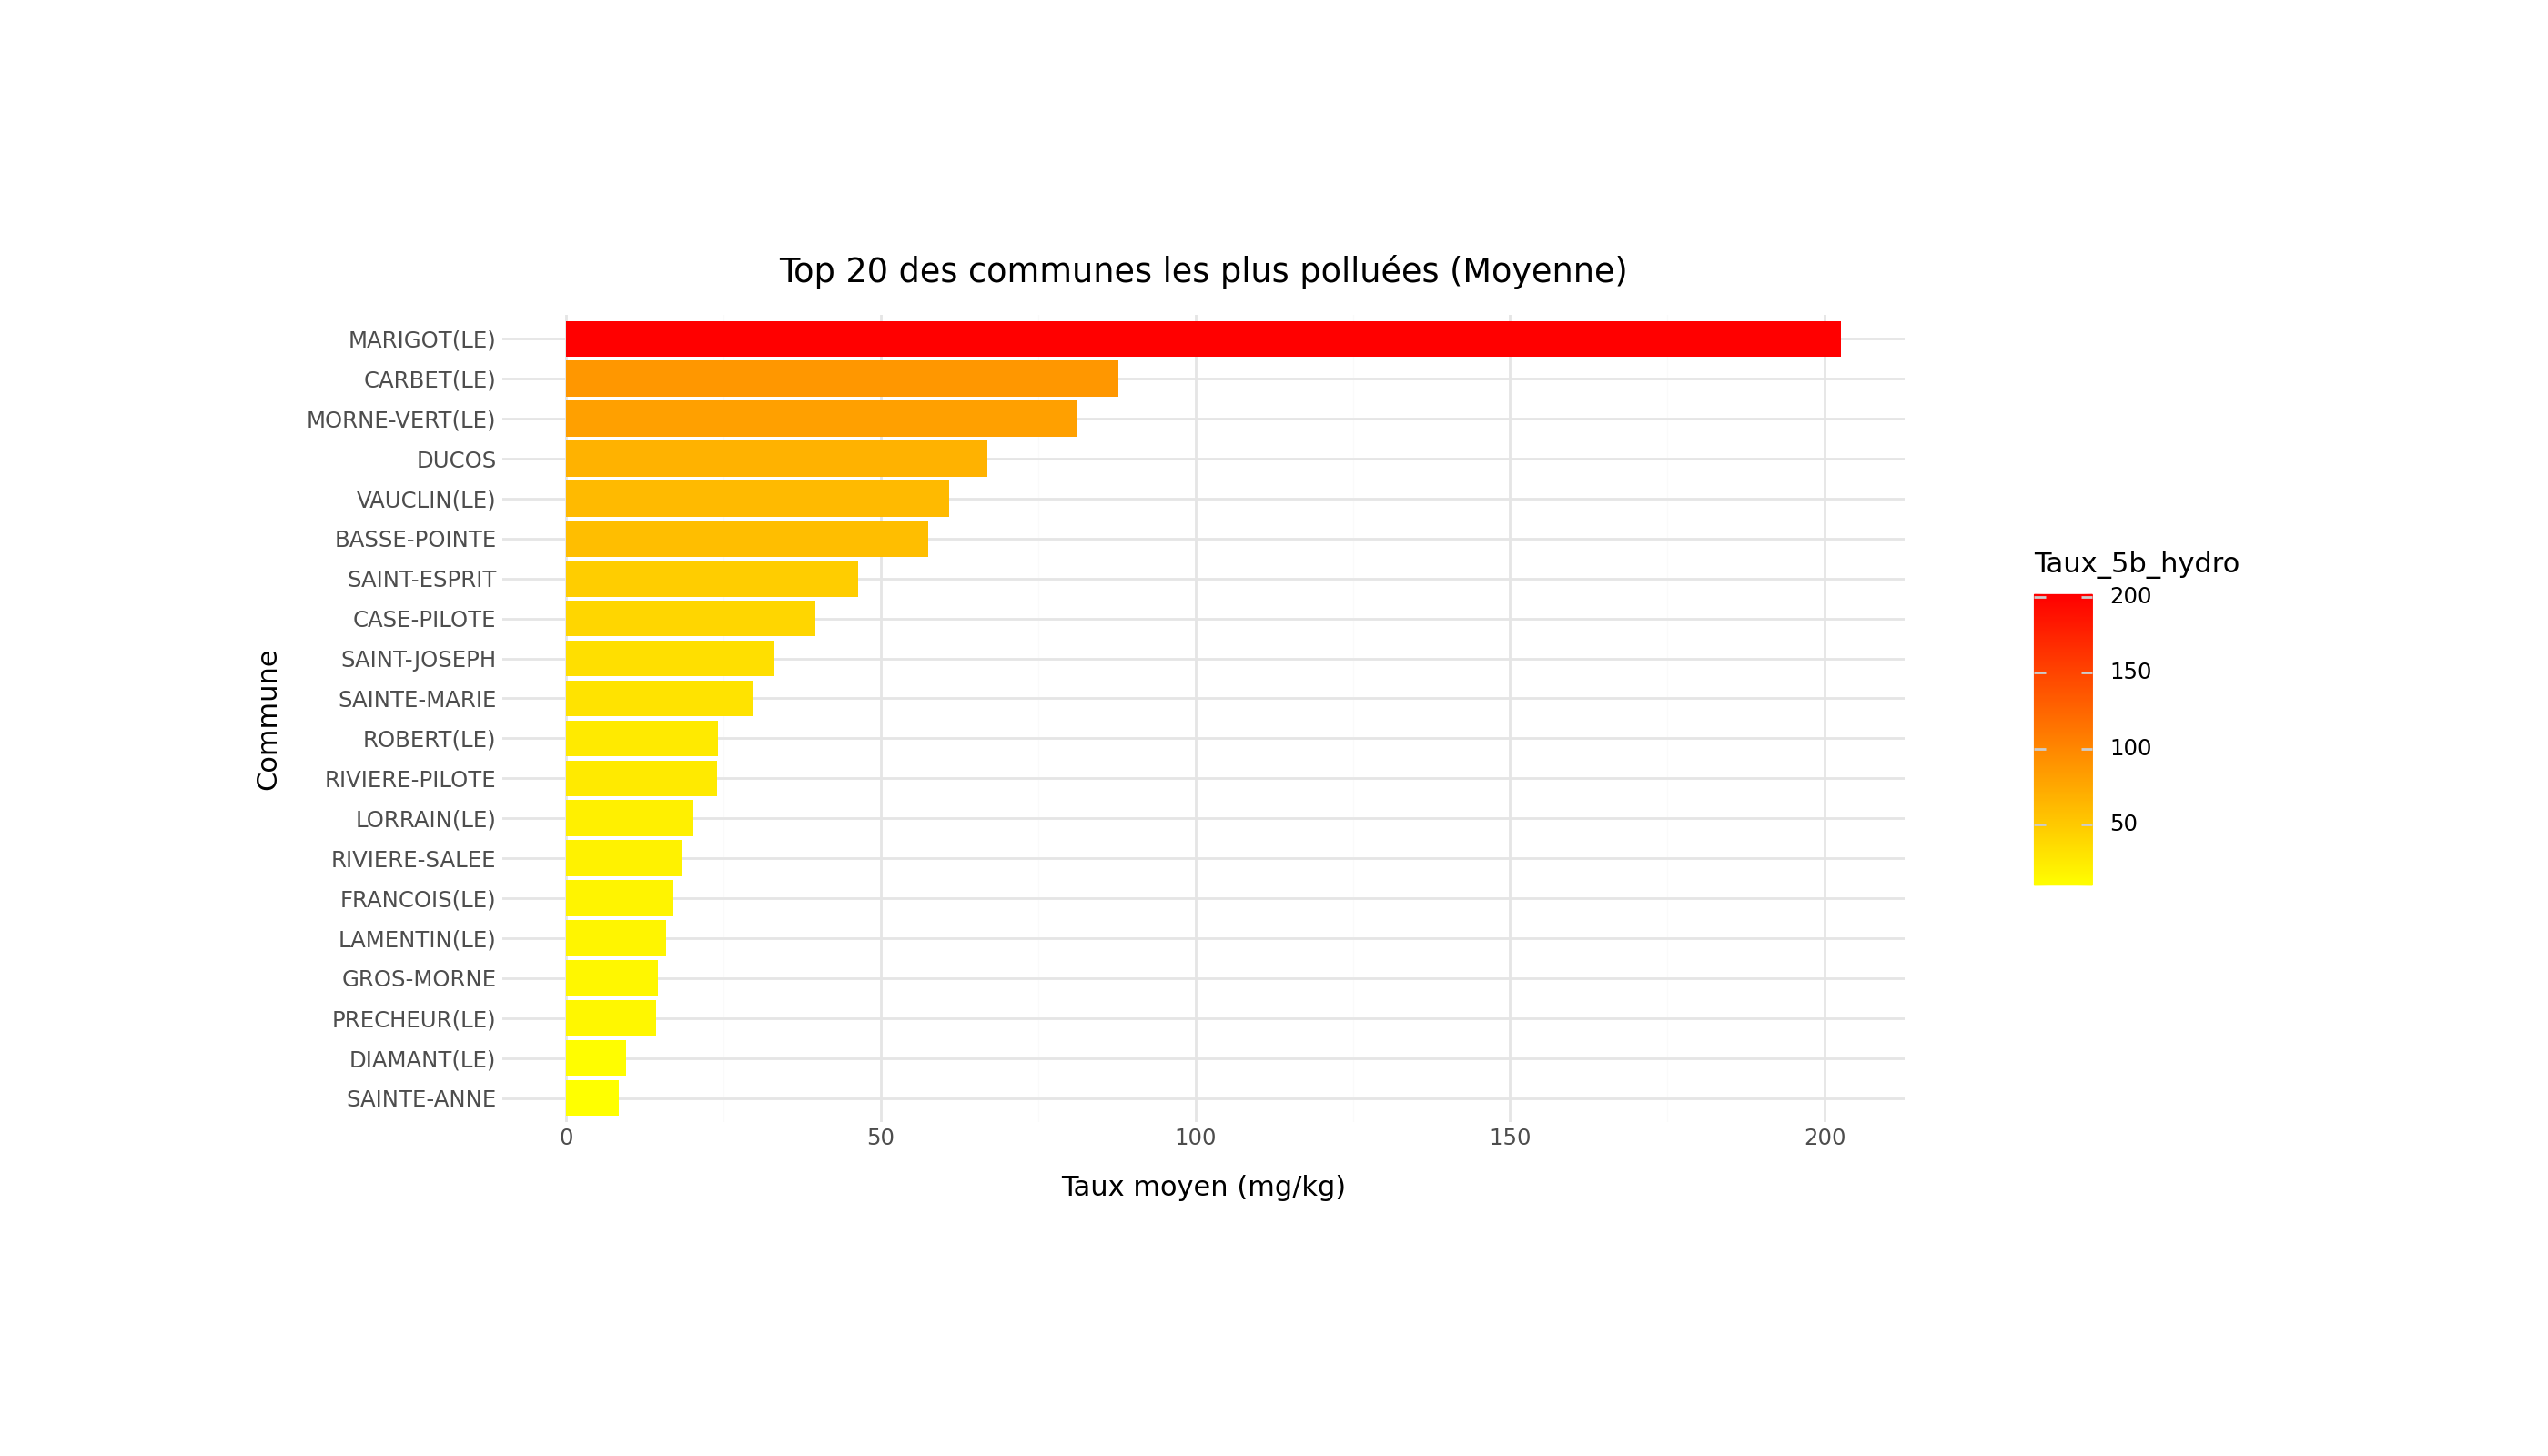

In [5]:
# Préparation des données
df_top20 = df.groupby('COMMU_LAB')['Taux_5b_hydro'].mean().sort_values(ascending=False).head(20).reset_index()

# Graphique
(
    ggplot(df_top20, aes(x='reorder(COMMU_LAB, Taux_5b_hydro)', y='Taux_5b_hydro', fill='Taux_5b_hydro'))
    + geom_col()
    + coord_flip() 
    + scale_fill_gradient(low="yellow", high="red")
    + labs(title="Top 20 des communes les plus polluées (Moyenne)",
           x="Commune", y="Taux moyen (mg/kg)")
    + theme_minimal()
    + theme(
        figure_size=(14, 8),         
        plot_margin=0.1,        
        legend_position='right',      
        legend_box_margin=20         
    )
)

Le Marigot le Carbet et Morne-Vert sont les plus pollués
Mais ce classement est est fait sur la moyenne.
Alors que la moyenne peut etre influée par les valeur extreme
Essayons de faire le classement suivant la médiane qui est moins biaisée par les caleurs extremes 

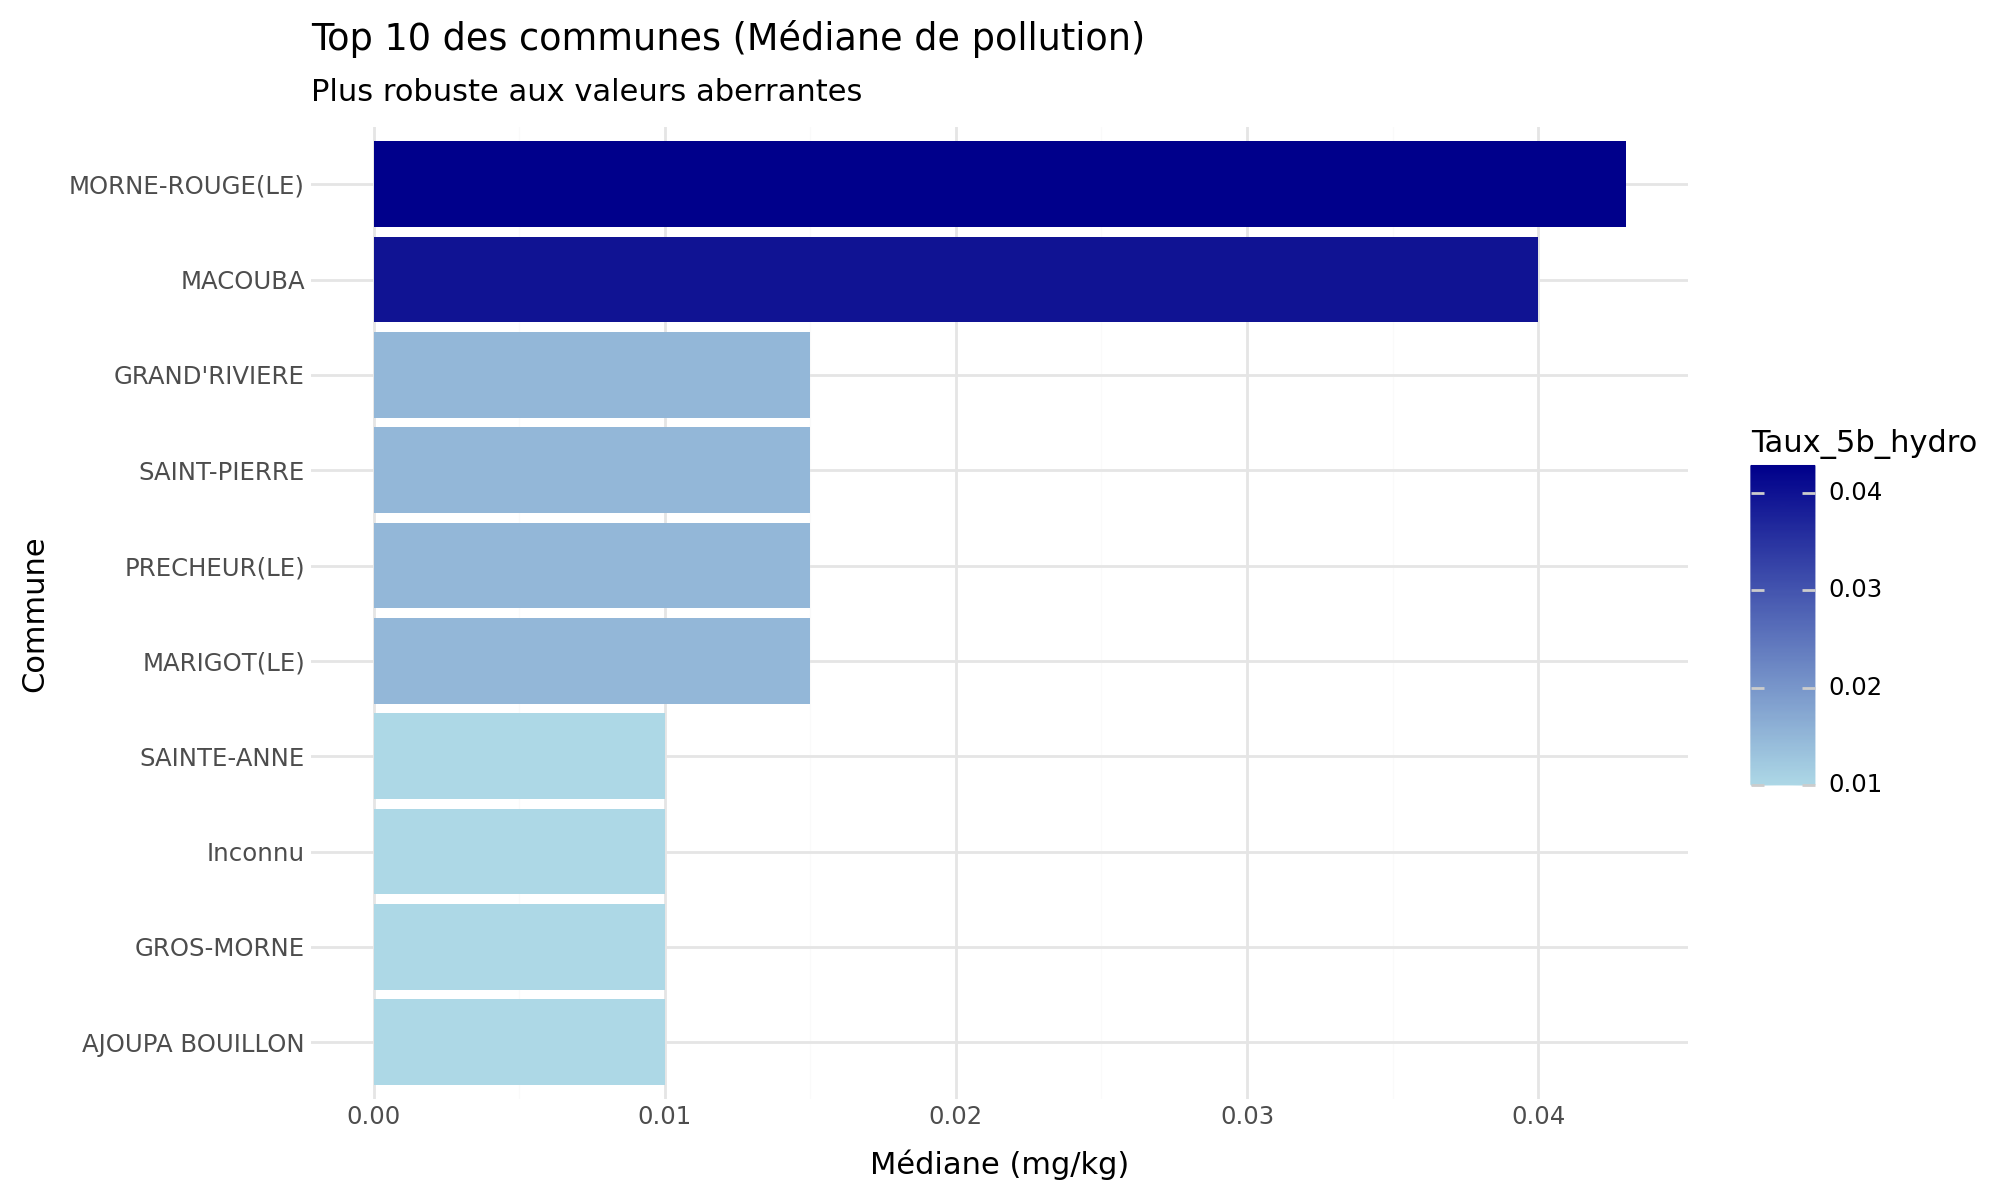

In [7]:
df_mediane = df.groupby('COMMU_LAB')['Taux_5b_hydro'].median().sort_values(ascending=False).head(10).reset_index()

(
    ggplot(df_mediane, aes(x='reorder(COMMU_LAB, Taux_5b_hydro)', y='Taux_5b_hydro', fill='Taux_5b_hydro'))
    + geom_col()
    + coord_flip() 
    + scale_fill_gradient(low="lightblue", high="darkblue")
    + labs(title="Top 10 des communes (Médiane de pollution)",
           subtitle="Plus robuste aux valeurs aberrantes",
           x="Commune", y="Médiane (mg/kg)")
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        legend_position='right'
    )
)

Le classement a changé. Ici on constate maintenant que LE MARIGOT est classé 6em parmis les communes les plus polluées et une commune comme LE PRECHEUR (anciennement 17em) vient apparaitre maintenant dans le TOP 5

Maintenant intéressons nous aux types de sols pour voir s'ils ont une influence sur la pollution

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 1336 rows containing non-finite values.


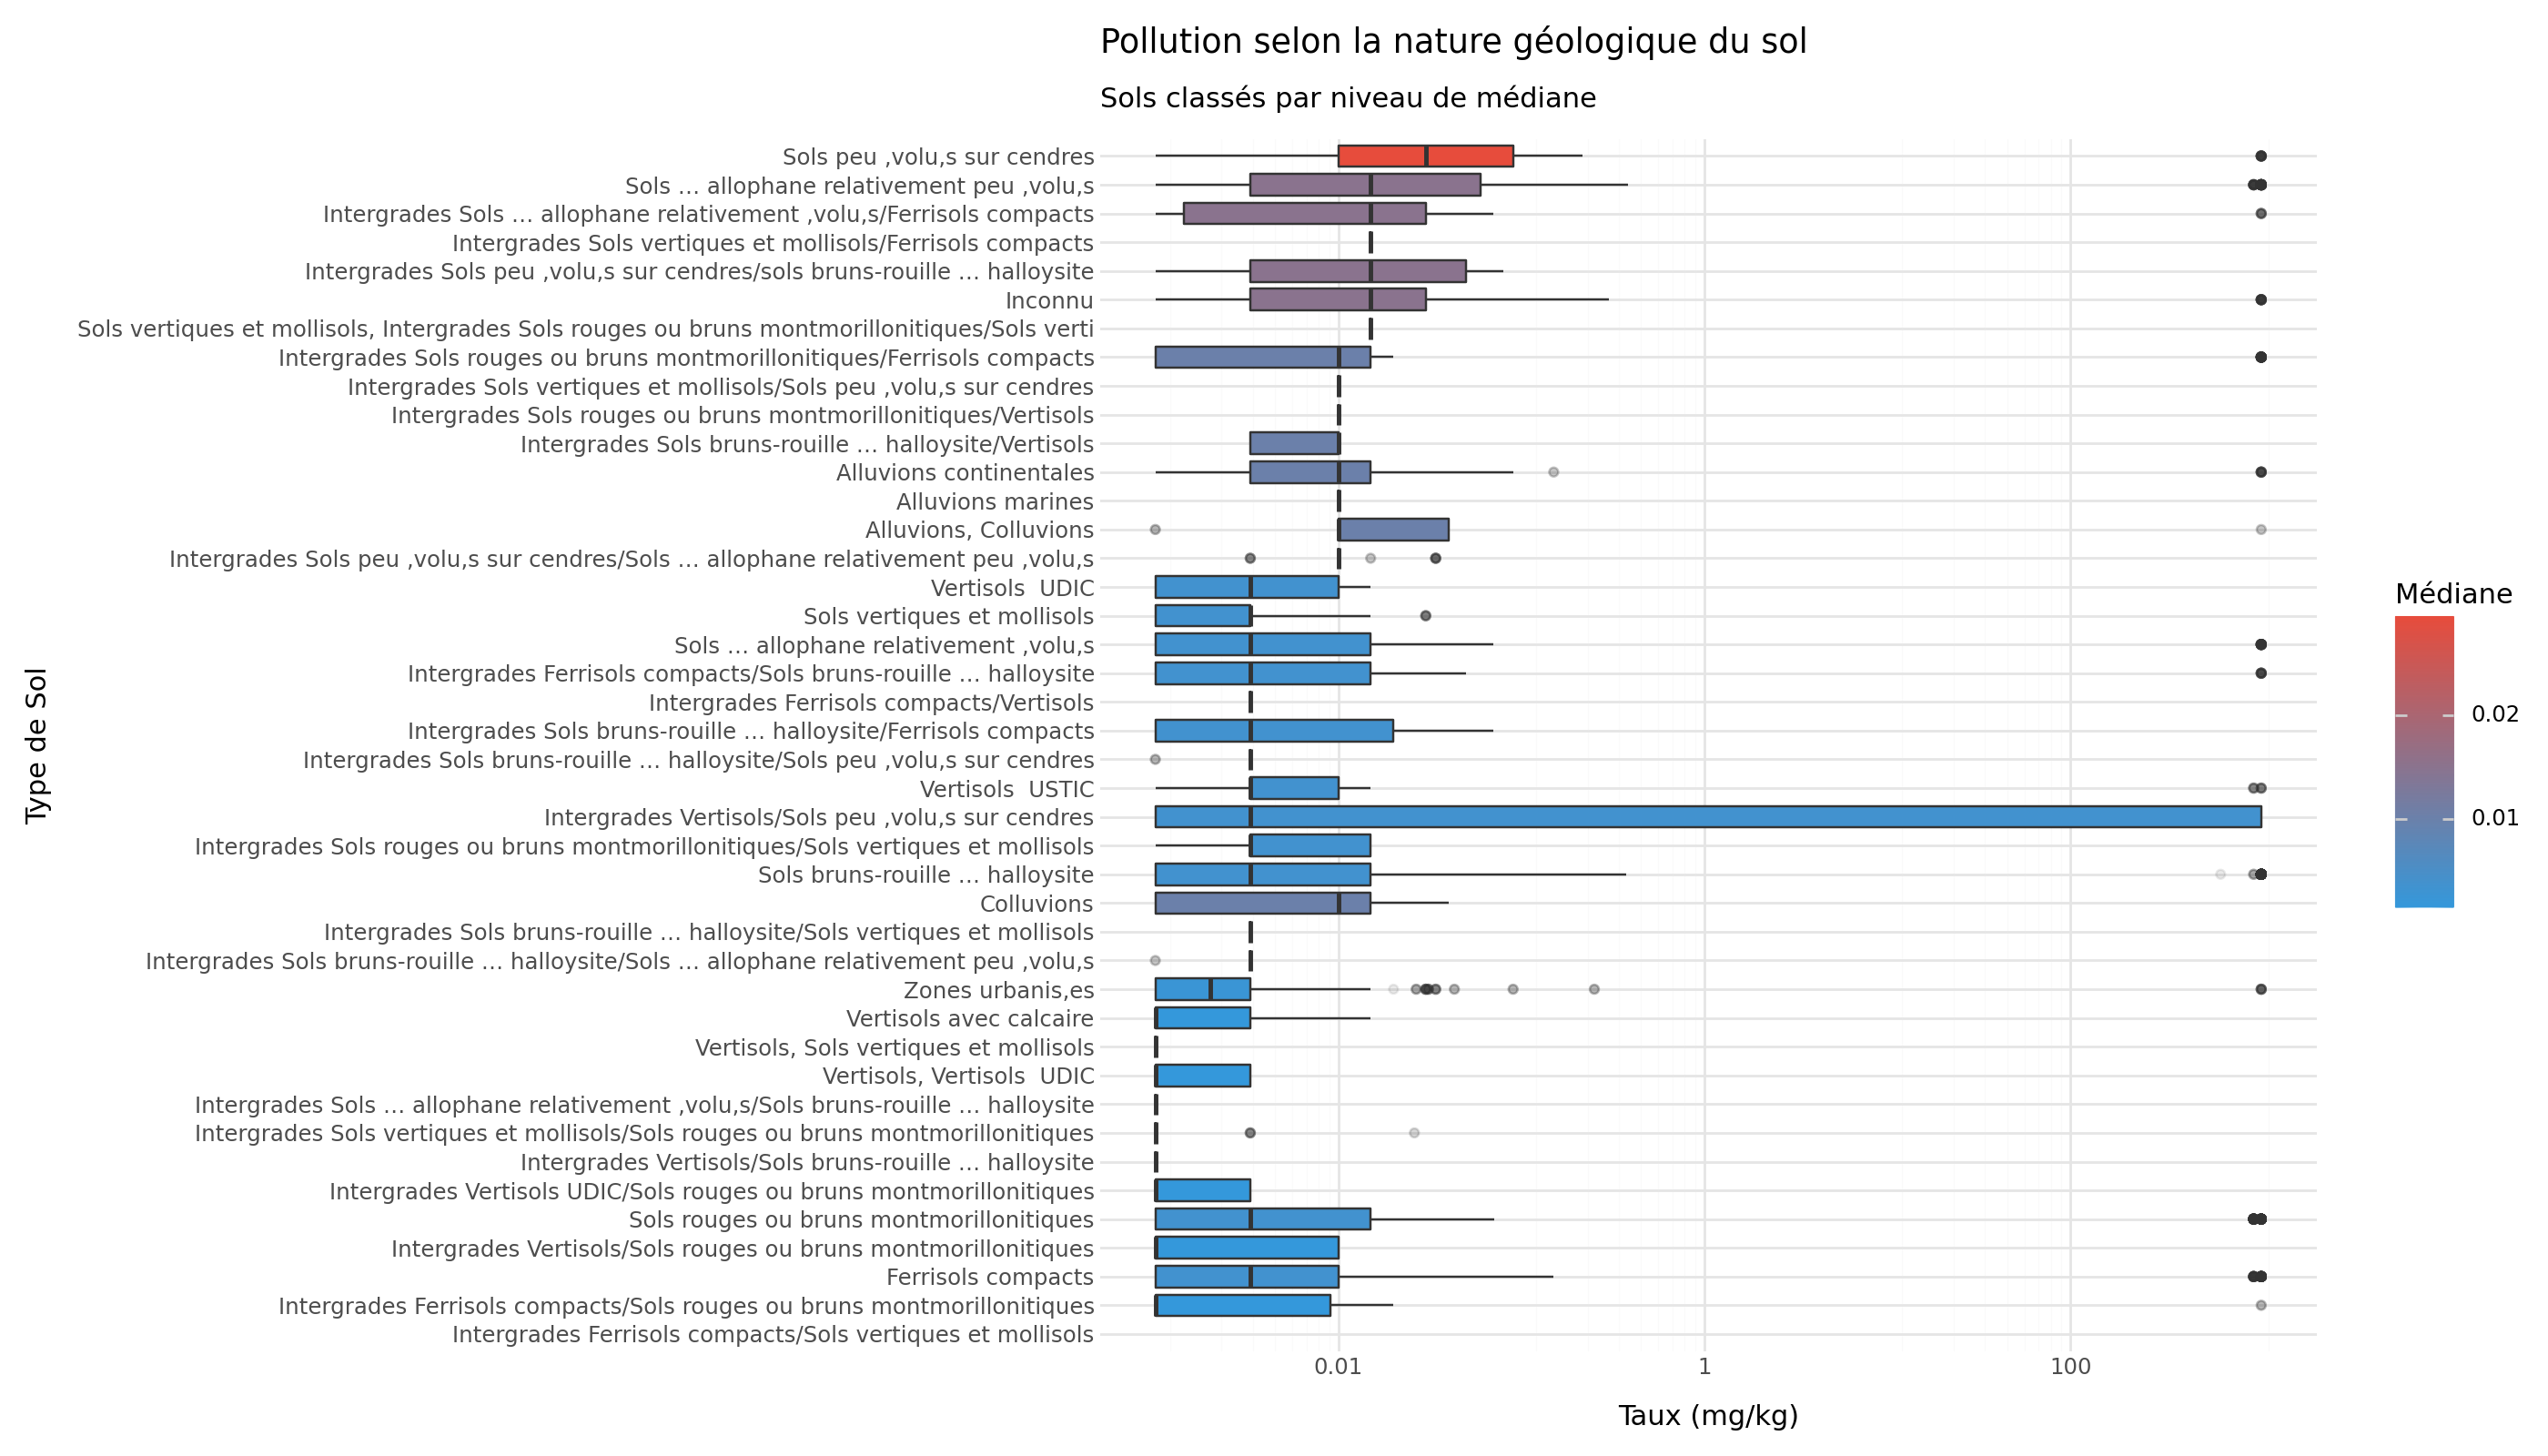

In [8]:
# 1. On définit l'ordre des sols pour que le graphique soit lisible
sol_ordre = df.groupby('type_sol')['Taux_5b_hydro'].median().sort_values().index.tolist()

# 2. Le graphique corrigé
(
    ggplot(df, aes(x='type_sol', y='Taux_5b_hydro'))
    + geom_boxplot(
        aes(fill='stat(middle)'), # L'esthétique (aes) en premier
        outlier_alpha=0.1         # Le paramètre fixe en second
    )
    + scale_y_log10()
    + coord_flip()
    + scale_x_discrete(limits=sol_ordre)
    + scale_fill_gradient(low="#3498db", high="#e74c3c") # Un beau dégradé Bleu -> Rouge
    + labs(
        title="Pollution selon la nature géologique du sol",
        subtitle="Sols classés par niveau de médiane",
        x="Type de Sol", 
        y="Taux (mg/kg)",
        fill="Médiane"
    )
    + theme_minimal()
    + theme(figure_size=(14, 8))
)

Ici on a le classement des sols par le taux médian de 5b_hydro chloredecone

In [9]:
# 1. Création du tableau de synthèse (Regroupement par commune)
df_synthese = df.groupby('COMMU_LAB').agg({
    'Taux_5b_hydro': 'median',       # La médiane (plus robuste)
    'mnt_pente_mean': 'mean',        # La pente moyenne du relief
    'type_sol': lambda x: x.mode()[0] if not x.mode().empty else "Inconnu" # Le sol dominant
}).reset_index()

# 2. On sélectionne le Top 10 par taux de pollution
top_10_synthese = df_synthese.sort_values(by='Taux_5b_hydro', ascending=False).head(10)

# 3. On renomme pour que ce soit joli dans ton rapport
top_10_synthese.columns = ['Commune', 'Médiane (mg/kg)', 'Pente Moyenne (°)', 'Sol Dominant']

# 4. Affichage simple et propre
top_10_synthese

,Commune,Médiane (mg/kg),Pente Moyenne (°),Sol Dominant
20,MORNE-ROUGE(LE),0.043,21.414211,Sols … allophane relativement peu ‚volu‚s
17,MACOUBA,0.040,20.752531,Sols peu ‚volu‚s sur cendres
11,GRAND'RIVIERE,0.015,42.875545,Inconnu
18,MARIGOT(LE),0.015,22.443561,Sols bruns-rouille … halloysite
22,PRECHEUR(LE),0.015,22.013364,Sols peu ‚volu‚s sur cendres
28,SAINT-PIERRE,0.015,26.079294,Sols peu ‚volu‚s sur cendres
14,Inconnu,0.010,19.111903,Sols … allophane relativement peu ‚volu‚s
0,AJOUPA BOUILLON,0.010,21.843795,Sols … allophane relativement peu ‚volu‚s
29,SAINTE-ANNE,0.010,10.491005,Vertisols USTIC
12,GROS-MORNE,0.010,18.864714,Sols … allophane relativement ‚volu‚s


Ce tableau montre les types de sols influent plus sur les taux_5b_hydro que le relief : la géologie domine le relief.

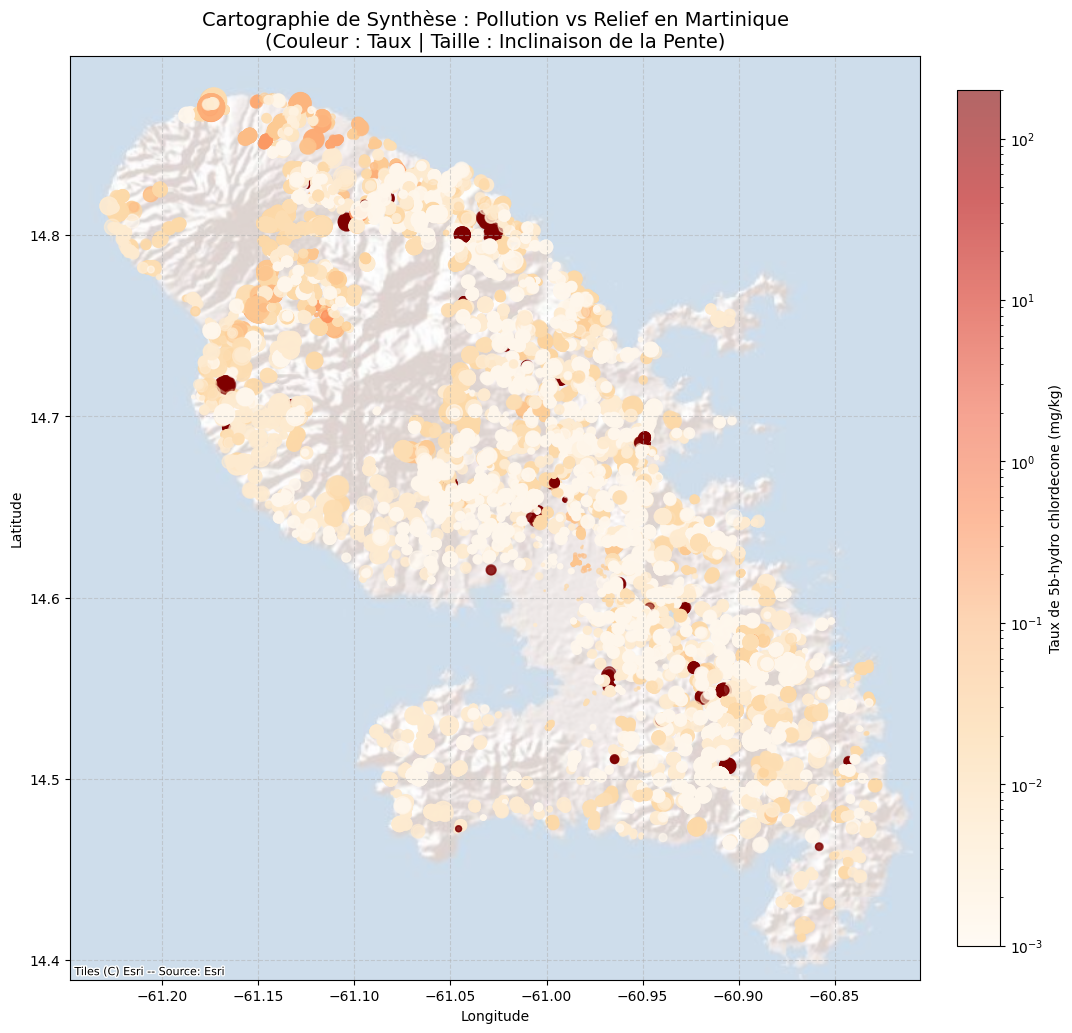

In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# ---  Préparation 
crs_init = "EPSG:5490" # Lambert 97 (Martinique)

# Conversion de Pandas à GeoPandas (Points Géographiques)
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['X'], df['Y']), 
    crs=crs_init
)

# Recalcul des coordonnées en GPS standard pour la fond de carte (Si besoin)
if crs_init == "EPSG:5490":
    gdf = gdf.to_crs(epsg=4326)

# --- Création de la Carte ---

fig, ax = plt.subplots(figsize=(12, 12))

# Affichage des points de prélèvement
# Couleur = Taux (échelle log pour les contrastes) | Taille = Pente (visibilité du relief)
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['Taux_5b_hydro'],         # Couleur = Pollution
    cmap='OrRd',                   # Dégradé Jaune (bas) -> Rouge (haut)
    s=gdf['mnt_pente_mean'] * 3,   # Taille du point = Force de la pente
    alpha=0.6, 
    norm=plt.matplotlib.colors.LogNorm(vmin=0.001, vmax=200) # Échelle logarithmique pour les couleurs
)

#  Ajout de la barre de légende des couleurs (Taux)
colorbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
colorbar.set_label('Taux de 5b-hydro chlordecone (mg/kg)')

#  Ajout d'un fond de carte de relief (Terrain)
# On utilise un fond qui montre bien les courbes de niveau (comme une carte MNT ombrée)
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Esri.WorldShadedRelief, alpha=0.5)

# Titre et labels propres pour ton rapport
plt.title("Cartographie de Synthèse : Pollution vs Relief en Martinique\n(Couleur : Taux | Taille : Inclinaison de la Pente)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

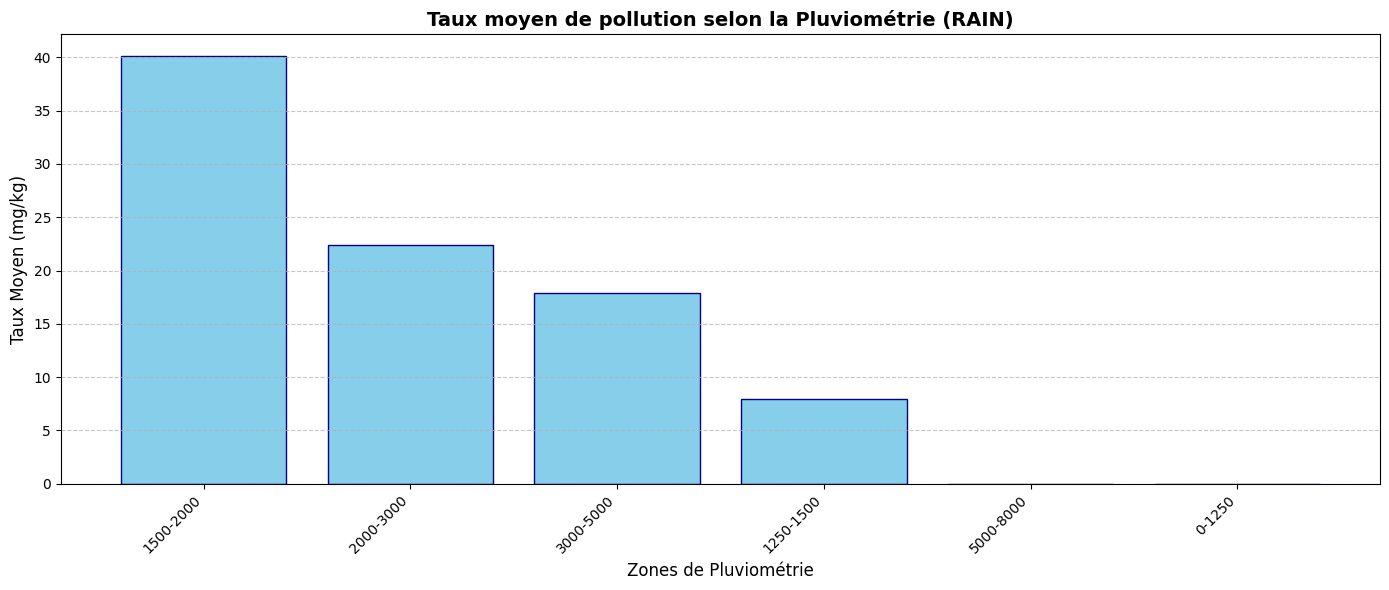

In [13]:
import matplotlib.pyplot as plt

# 1. Préparation des données : Moyenne du taux par groupe de pluie
# On groupe par la colonne 'RAIN' et on calcule la moyenne du 'Taux_5b_hydro'
df_pluie = df.groupby('RAIN')['Taux_5b_hydro'].mean().sort_values(ascending=False)

# 2. Création du graphique
plt.figure(figsize=(14, 6))

# On trace les barres (bâtons)
plt.bar(df_pluie.index, df_pluie.values, color='skyblue', edgecolor='navy')

# 3. Personnalisation (Habillage)
plt.title("Taux moyen de pollution selon la Pluviométrie (RAIN)", fontsize=14, fontweight='bold')
plt.xlabel("Zones de Pluviométrie", fontsize=12)
plt.ylabel("Taux Moyen (mg/kg)", fontsize=12)

# Rotation des étiquettes X si elles sont trop longues
plt.xticks(rotation=45, ha='right')

# Ajout d'une grille horizontale pour mieux lire les valeurs
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustement pour ne pas couper les textes
plt.tight_layout()

plt.show()

Les zones qui ont des pluviométries entre 1500mm et 5000mm ont des concentration de chloredécone plus élevées.

Les zones ayant des concentrations inférieurs à 1500mm ont un taux de pollution très faible.

Ce sont des zones séches qui n'étais pas destinés à la culture du banane

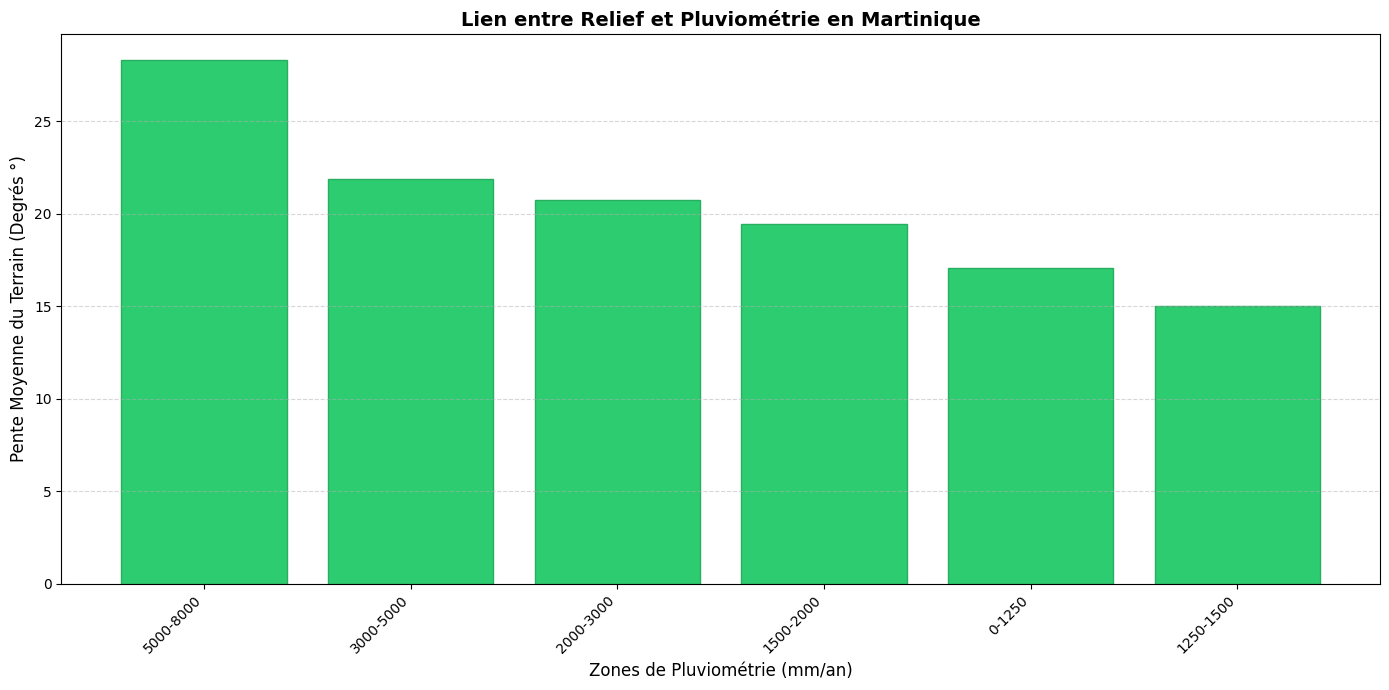

In [14]:
import matplotlib.pyplot as plt


# grouper par 'RAIN' et on calcule la moyenne de 'mnt_pente_mean'
df_relief_pluie = df.groupby('RAIN')['mnt_pente_mean'].mean().sort_values(ascending=False)

# Création du graphique
plt.figure(figsize=(14, 7))

# traçage des bâtons
plt.bar(df_relief_pluie.index, df_relief_pluie.values, color='#2ecc71', edgecolor='#27ae60')

# Personnalisation technique
plt.title("Lien entre Relief et Pluviométrie en Martinique", fontsize=14, fontweight='bold')
plt.xlabel("Zones de Pluviométrie (mm/an)", fontsize=12)
plt.ylabel("Pente Moyenne du Terrain (Degrés °)", fontsize=12)

# Rotation des étiquettes pour la lisibilité
plt.xticks(rotation=45, ha='right')

# Ajout d'une grille pour la précision de lecture
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajustement des marges
plt.tight_layout()

plt.show()

En Martinique, le relief est le moteur du climat.

Les zones ayant des pentes très élevées ont plus de précipitations
Dans ces zones les pluies font un lessivage des sols avec le ruissellement des eaux

Tandis que dans les zones basses ont de très faibles pluviométries ce qui n'encourage pas la culture dans ces zones

Ce sont les zones aux  pentes modéres et à moyenne pluviométrie qui sont plus pollués 

Synthèse :

Le relief et la pluviométrie agissent comme des curseurs de l'activité humaine passée notammant la culture des bananeraies.

La chlordécone se concentre dans les zones de transition (pentes modérées de 18-20° et pluviométrie de 1500-2000 mm) et certaines types de sol comme les andosols, qui offraient les conditions optimales pour la culture bananière.

 Les zones de relief extrême (>25°), bien que plus arrosées, ont été préservées par leur inaccessibilité, tandis que les zones plates et sèches du Sud n'aurait pas accueilli ces cultures.